Getting this data into a usable CSV was a massive headache. I initially tried to manually extract the data from the State Fair competition PDFs, but quickly ran into issues. After standard PDF extractors failed too, I realized using an LLM was my best bet. I gathered all the archival data I could find from 2019 to 2025 and loaded it into NotebookLM. Since it uses Gemini, it could handle the large batch of files effectively. I had it pull everything into a file with the contestant name, city, class number, class name, year, placement, subcategory, and entries in class.

From there, I did a quick initial sort in Excel by year, class number, and placement.

Going into this analysis, there are two major hurdles. First, there are a couple of missing years in the dataset; there were no canning competitions in 2020 because of Covid, and for some reason, the 2024 data just does not exist anywhere online. Second, the data only includes people who actually placed. I am going to have to find a way to control for the fact that we have zero data on the rest of the entrants.

In [1]:
# Load in my libraries

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the CSV file
df = pd.read_csv('../data/StateFairCanningCompetitionResults.csv')

# Display the first few rows
df.head()

,Contestant Name,City,Class Number,Class Name,Year,Placement,Subcategory,Entries in Class
0,Barb Schaller,"Burnsville, MN",1200,Prestigious Processor of the Pantry,2019,1,Canning,NaN
1,Sonja Wieber,"Plymouth, MN",1201,"Applesauce, no other additions other than sugar",2019,1,Fruits,10.0
2,Joe Smithwick,"Cottage Grove, MN",1201,"Applesauce, no other additions other than sugar",2019,2,Fruits,10.0
3,Laura Ackerman,"Cottage Grove, MN",1201,"Applesauce, no other additions other than sugar",2019,3,Fruits,10.0
4,Mary Von Fischer,"Saint Paul, MN",1201,"Applesauce, no other additions other than sugar",2019,4,Fruits,10.0


In [3]:
# Data checks
print("DataFrame shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
df.describe(include='all')

DataFrame shape: (1664, 8)

Data types:
Contestant Name         str
City                    str
Class Number          int64
Class Name              str
Year                  int64
Placement             int64
Subcategory             str
Entries in Class    float64
dtype: object

Missing values:
Contestant Name      0
City                 0
Class Number         0
Class Name           0
Year                 0
Placement            0
Subcategory          0
Entries in Class    27
dtype: int64

Descriptive statistics:


,Contestant Name,City,Class Number,Class Name,Year,Placement,Subcategory,Entries in Class
count,1664,1664,1664.000000,1664,1664.000000,1664.000000,1664,1637.000000
unique,385,136,NaN,134,NaN,NaN,18,NaN
top,Barb Schaller,"Minneapolis, MN",NaN,Blackberry,NaN,NaN,Jams,NaN
freq,55,227,NaN,42,NaN,NaN,443,NaN
mean,NaN,NaN,1323.900841,NaN,2021.945913,2.513822,NaN,13.980452
std,NaN,NaN,826.073232,NaN,1.986898,1.191694,NaN,8.931530
min,NaN,NaN,1200.000000,NaN,2019.000000,1.000000,NaN,1.000000
25%,NaN,NaN,1222.000000,NaN,2021.000000,1.000000,NaN,8.000000
50%,NaN,NaN,1242.000000,NaN,2022.000000,2.000000,NaN,11.000000
75%,NaN,NaN,1264.000000,NaN,2023.000000,4.000000,NaN,18.000000


I think those 27 entires in Class are non-competition rows for tracking other things (e.g., maybe an judge). I'll need to investigate those further

In [4]:
# Create a new column for region categorization
def categorize_city(city):
    if pd.isna(city):
        return 'Greater Minnesota'
    city_name = city.split(',')[0].strip()
    if city_name in ['Minneapolis', 'Saint Paul']:
        return 'Twin Cities Metro'
    else:
        return 'Greater Minnesota'

df['Region'] = df['City'].apply(categorize_city)

# Display the updated DataFrame with the new column
df.head()

,Contestant Name,City,Class Number,Class Name,Year,Placement,Subcategory,Entries in Class,Region
0,Barb Schaller,"Burnsville, MN",1200,Prestigious Processor of the Pantry,2019,1,Canning,NaN,Greater Minnesota
1,Sonja Wieber,"Plymouth, MN",1201,"Applesauce, no other additions other than sugar",2019,1,Fruits,10.0,Greater Minnesota
2,Joe Smithwick,"Cottage Grove, MN",1201,"Applesauce, no other additions other than sugar",2019,2,Fruits,10.0,Greater Minnesota
3,Laura Ackerman,"Cottage Grove, MN",1201,"Applesauce, no other additions other than sugar",2019,3,Fruits,10.0,Greater Minnesota
4,Mary Von Fischer,"Saint Paul, MN",1201,"Applesauce, no other additions other than sugar",2019,4,Fruits,10.0,Twin Cities Metro


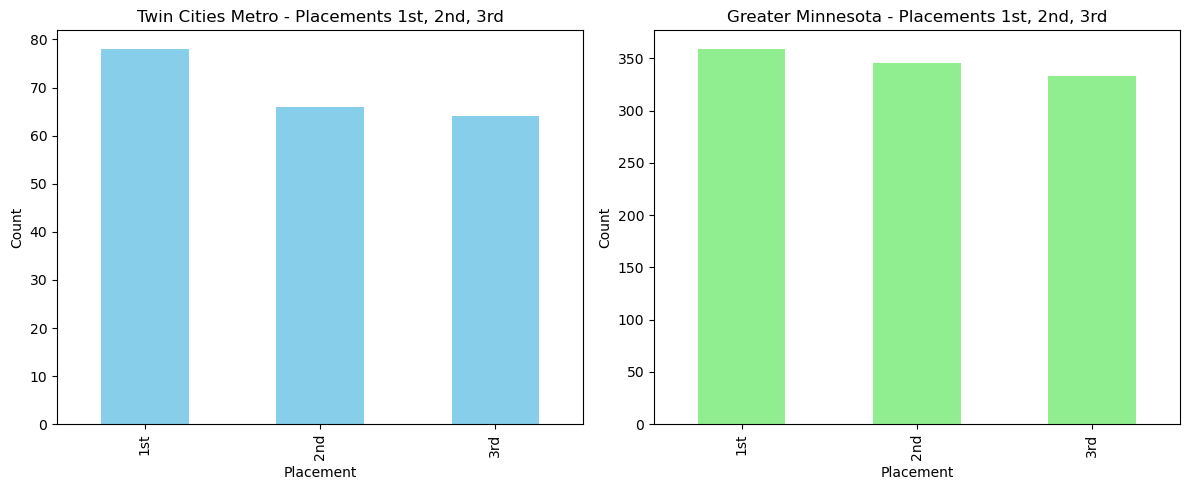

In [5]:
# Bar charts for placements by region
# Filter for top 3 placements
top_placements = df[df['Placement'].isin([1, 2, 3])]

# Count placements by region
placement_counts = top_placements.groupby(['Region', 'Placement']).size().unstack(fill_value=0)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Twin Cities Metro
placement_counts.loc['Twin Cities Metro'].plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Twin Cities Metro - Placements 1st, 2nd, 3rd')
axes[0].set_xlabel('Placement')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['1st', '2nd', '3rd'])

# Greater Minnesota
placement_counts.loc['Greater Minnesota'].plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Greater Minnesota - Placements 1st, 2nd, 3rd')
axes[1].set_xlabel('Placement')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['1st', '2nd', '3rd'])

plt.tight_layout()
plt.show()

I'm not sure what this gives me. I'm initially seeing that there's a larger jump for Twin Cities Netri between 2nd and 1st in comparison to Greater Minnesota.

In [6]:
# Descriptive statistics comparison between regions
print("=== Region Comparison Statistics ===")
print("\nTotal entries by region:")
print(df['Region'].value_counts())

print("\nAverage placement by region:")
print(df.groupby('Region')['Placement'].mean())

print("\nPlacement distribution by region:")
placement_dist = df.groupby('Region')['Placement'].describe()
print(placement_dist)

print("\nSubcategory distribution by region:")
subcat_dist = df.groupby(['Region', 'Subcategory']).size().unstack(fill_value=0)
print(subcat_dist)

print("\nYear distribution by region:")
year_dist = df.groupby(['Region', 'Year']).size().unstack(fill_value=0)
print(year_dist)

=== Region Comparison Statistics ===

Total entries by region:
Region
Greater Minnesota    1371
Twin Cities Metro     293
Name: count, dtype: int64

Average placement by region:
Region
Greater Minnesota    2.504741
Twin Cities Metro    2.556314
Name: Placement, dtype: float64

Placement distribution by region:
                    count      mean       std  min  25%  50%  75%  max
Region                                                                
Greater Minnesota  1371.0  2.504741  1.188362  1.0  1.0  2.0  3.0  5.0
Twin Cities Metro   293.0  2.556314  1.208306  1.0  1.0  3.0  4.0  5.0

Subcategory distribution by region:
Subcategory        Butters  Canning  Canning with Mrs. Wages Contest  \
Region                                                                 
Greater Minnesota       33        5                                4   
Twin Cities Metro        8        0                                2   

Subcategory        Dried Items  Dried items  Fermented Products  Fruits  \
Reg

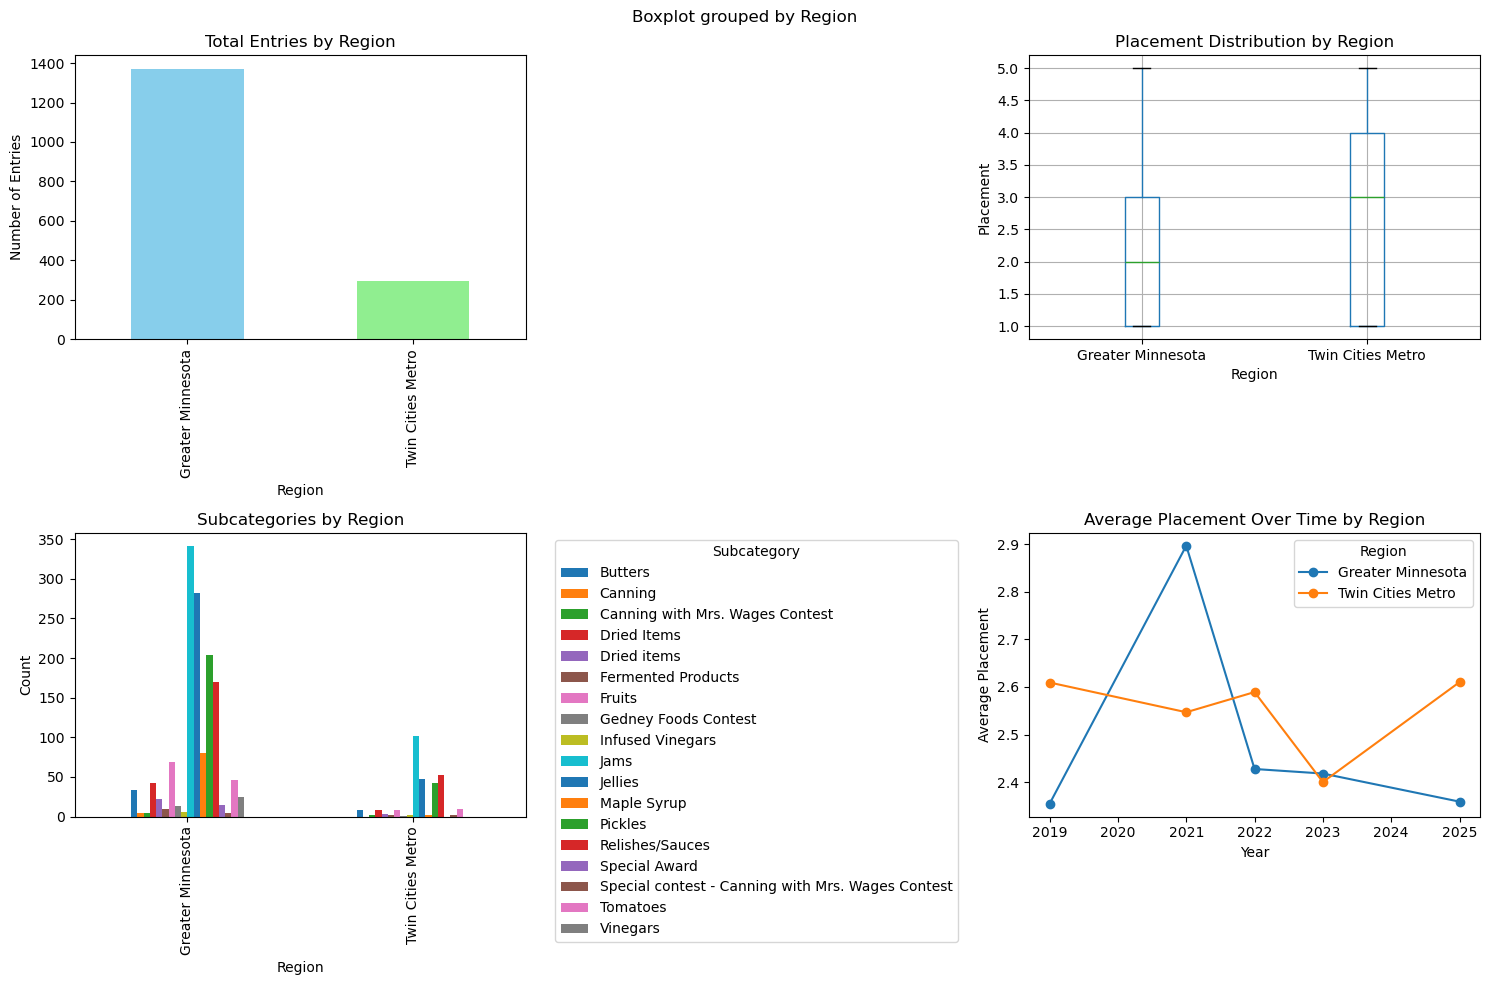

In [7]:
# Visual comparisons between regions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Total entries by region
region_counts = df['Region'].value_counts()
region_counts.plot(kind='bar', ax=axes[0,0], color=['skyblue', 'lightgreen'])
axes[0,0].set_title('Total Entries by Region')
axes[0,0].set_ylabel('Number of Entries')

# 2. Box plot of placements by region
df.boxplot(column='Placement', by='Region', ax=axes[0,1])
axes[0,1].set_title('Placement Distribution by Region')
axes[0,1].set_ylabel('Placement')

# 3. Subcategory breakdown by region
subcat_by_region = df.groupby(['Region', 'Subcategory']).size().unstack(fill_value=0)
subcat_by_region.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Subcategories by Region')
axes[1,0].set_ylabel('Count')
axes[1,0].legend(title='Subcategory', bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Average placement by year and region
avg_placement_year = df.groupby(['Year', 'Region'])['Placement'].mean().unstack()
avg_placement_year.plot(ax=axes[1,1], marker='o')
axes[1,1].set_title('Average Placement Over Time by Region')
axes[1,1].set_ylabel('Average Placement')
axes[1,1].legend(title='Region')

plt.tight_layout()
plt.show()